In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

print("Oilsands Production Optimizer")
print("=========================================")
print("Portfolio project for Alberta Oil and Gas Industry")
print("By: [Stephen Mtsor]")
print("Date: [Marrch, 2026]")
print("=========================================")

#Load the AER Oil Sands Production data from the CSV file
df_production = pd.read_csv('ST39.csv', encoding='latin-1')
print(f"AER data loaded successfully: {df_production.shape[0]} rows, {df_production.shape[1]} columns")



Oilsands Production Optimizer
Portfolio project for Alberta Oil and Gas Industry
By: [Stephen Mtsor]
Date: [Marrch, 2026]
AER data loaded successfully: 1671 rows, 14 columns


In [33]:

#Data preprocessing: Monthly bitumen production dataset generated for 6 major oil sands facilities over 5 years (2020-2024)
dates =pd.date_range('2020-01-01', periods=60, freq='MS')
facilities = ['Fort Hills', 'Kearl', 'Mildred Lake', 'Syncrude', 'Suncor', 'Total E&P Canada']
df_Bitumen = pd.DataFrame({
    'Date': dates.tolist() * len(facilities),
    'Facility': facilities * len(dates),
    'Bitumen_m3d': np.random.uniform(10000, 50000, size=len(dates) * len(facilities))  
})
df_Bitumen['Date'] = pd.to_datetime(df_Bitumen['Date'])

df_Bitumen['Year'] = df_Bitumen['Date'].dt.year

In [34]:


#Data cleaning: Remove rows with missing values in any of the bitumen production columns

df_Bitumen = df_Bitumen.dropna(subset = [col for col in df_Bitumen.columns
                                         if 'Bitumen' in str(col) or 'Production' in str(col)])

if 'Bitumen_m3d' not in df_Bitumen.columns:
    df_Bitumen['Bitumen_m3d'] = np.nan
    
print("\nData preview.")
print(df_Bitumen[['Date', 'Facility', 'Bitumen_m3d']].head())



Data preview.
        Date      Facility   Bitumen_m3d
0 2020-01-01    Fort Hills  37758.308359
1 2020-02-01         Kearl  36109.561277
2 2020-03-01  Mildred Lake  22257.086735
3 2020-04-01      Syncrude  24912.024316
4 2020-05-01        Suncor  14659.550103


In [39]:
#Summarize total bitumen production by year and facility

df_summary = df_Bitumen.groupby(
    'Facility')['Bitumen_m3d'].agg([
        'mean', 'sum', 'min', 'max', 'count']).round(0)
print("\nBitumen production summary by facility (m3/day):")
print(df_summary)

yearly_production = df_Bitumen.groupby(
    ['Year', 'Facility'])['Bitumen_m3d'].sum().round(0)
print("\nYearly bitumen production by facility (m3/year):")
print(yearly_production)


Bitumen production summary by facility (m3/day):
                     mean        sum      min      max  count
Facility                                                     
Fort Hills        27838.0  1670305.0  10185.0  48801.0     60
Kearl             29372.0  1762331.0  10920.0  49630.0     60
Mildred Lake      27934.0  1676064.0  10180.0  49670.0     60
Suncor            31485.0  1889110.0  11875.0  49993.0     60
Syncrude          30474.0  1828436.0  10062.0  49864.0     60
Total E&P Canada  30911.0  1854677.0  10203.0  49866.0     60

Yearly bitumen production by facility (m3/year):
Year  Facility        
2020  Fort Hills          349178.0
      Kearl               342776.0
      Mildred Lake        364550.0
      Suncor              381685.0
      Syncrude            359205.0
      Total E&P Canada    341161.0
2021  Fort Hills          241122.0
      Kearl               394326.0
      Mildred Lake        323902.0
      Suncor              362128.0
      Syncrude            35543

Text(0, 0.5, 'Frequency')

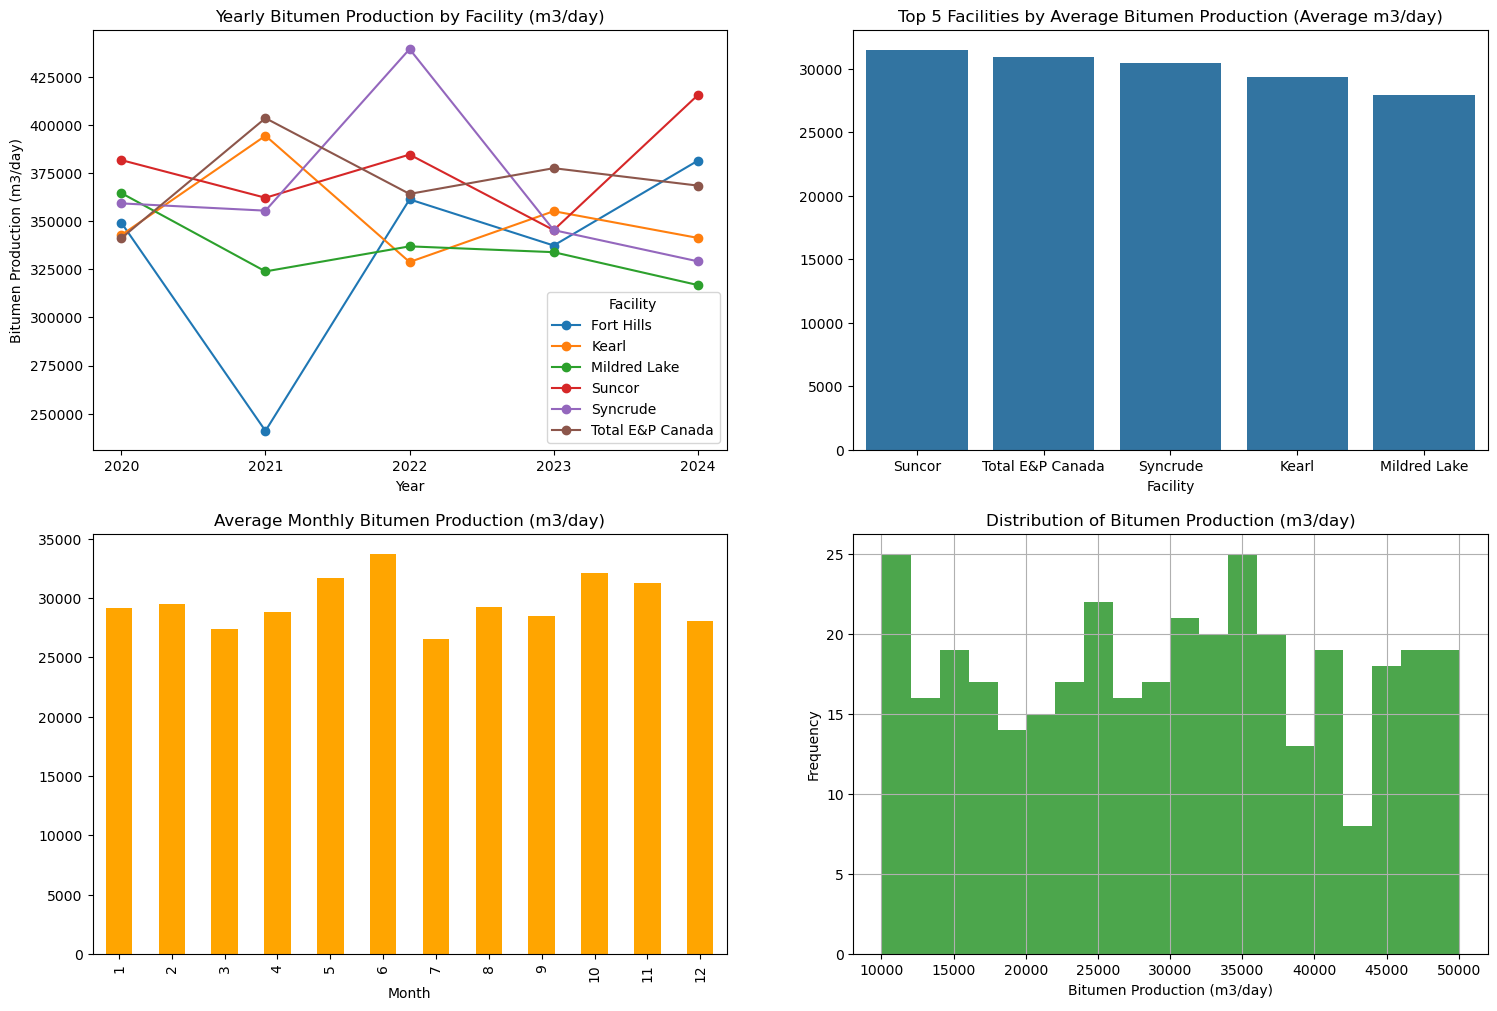

In [71]:
#Visualize production trends over time for each facility
fig,axes = plt.subplots(2, 2, figsize=(18, 12))

#Plot 1: Yearly total production trends
yearly_by_facility = df_Bitumen.groupby(
    ['Year', 'Facility']
    )['Bitumen_m3d'].sum().unstack()

yearly_by_facility.plot(ax=axes[0,0], marker='o')
axes[0,0].set_title('Yearly Bitumen Production by Facility (m3/day)')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Bitumen Production (m3/day)')
axes[0,0].legend(title='Facility')

axes[0, 0].set_xticks(yearly_by_facility.index)
axes[0, 0].set_xticklabels(yearly_by_facility.index.astype(int))


#Plot 2: Top 5 facilities by average production
top_5_facilities = df_summary['mean'].nlargest(5)
sns.barplot(x=top_5_facilities.index, y=top_5_facilities.values, ax=axes[0,1])
axes[0,1].set_title('Top 5 Facilities by Average Bitumen Production (Average m3/day)')


#Plot 3: Average monthly production trends
monthly_avg = df_Bitumen.groupby(df_Bitumen['Date'].dt.month)['Bitumen_m3d'].mean()
monthly_avg.plot(ax=axes[1,0], kind='bar', title='Average Monthly Bitumen Production (m3/day)', color='orange')
axes[1,0].set_xlabel('Month')

#Plot 4: Production distribution by facility
df_Bitumen['Bitumen_m3d'].hist(bins=20, ax=axes[1,1], alpha=0.7, color='green')
axes[1,1].set_title('Distribution of Bitumen Production (m3/day)')
axes[1,1].set_xlabel('Bitumen Production (m3/day)')
axes[1,1].set_ylabel('Frequency')
